In [1]:
import pandas as pd
import numpy as np

# Q1. Load dataset, identify ML problem, select target variable

In [2]:
df=pd.read_csv(r"C:\Users\rsant\Downloads\Crop Prediction Dataset.xls")

In [4]:
df.head()

,Record_ID,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production_per_Area,Rainfall_Category,Fertilizer_per_Area,Pesticide_per_Area,Yield_Category,Year_Group
0,1,Arecanut,1997,Whole Year,Assam,73814,56708,2051,7024878,22882.34,0.796087,0.768255,High,95.17,0.31,Low,1997-2000
1,2,Arhar/Tur,1997,Kharif,Assam,6637,4685,2051,631643,2057.47,0.710435,0.705891,High,95.17,0.31,Low,1997-2000
2,3,Castor seed,1997,Kharif,Assam,9378,22,2051,75755,246.76,0.238333,0.027638,High,95.17,0.31,Low,1997-2000
3,4,Coconut,1997,Whole Year,Assam,19656,126905000,2051,1870661,6093.36,0.982466,6456.298331,High,95.17,0.31,Very High,1997-2000
4,5,Cotton(lint),1997,Kharif,Assam,1739,794,2051,165500,539.09,0.420909,0.456584,High,95.17,0.31,Low,1997-2000


In [6]:
x= df.drop("Yield_Category", axis=1)

In [7]:
y=df["Yield_Category"]

#### Machine Learning Classification Problem

# Q2 Identify categorical and numeric columns + Encoding + Scaling

In [9]:
categorical_cols = x.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = x.select_dtypes(include=["int64", "float64"]).columns.tolist()


In [10]:
categorical_cols

['Crop', 'Season', 'State', 'Rainfall_Category', 'Year_Group']

In [11]:
numeric_cols

['Record_ID',
 'Crop_Year',
 'Area',
 'Production',
 'Annual_Rainfall',
 'Fertilizer',
 'Pesticide',
 'Yield',
 'Production_per_Area',
 'Fertilizer_per_Area',
 'Pesticide_per_Area']

In [12]:
x

,Record_ID,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production_per_Area,Rainfall_Category,Fertilizer_per_Area,Pesticide_per_Area,Year_Group
0,1,Arecanut,1997,Whole Year,Assam,73814,56708,2051,7024878,22882.34,0.796087,0.768255,High,95.17,0.31,1997-2000
1,2,Arhar/Tur,1997,Kharif,Assam,6637,4685,2051,631643,2057.47,0.710435,0.705891,High,95.17,0.31,1997-2000
2,3,Castor seed,1997,Kharif,Assam,9378,22,2051,75755,246.76,0.238333,0.027638,High,95.17,0.31,1997-2000
3,4,Coconut,1997,Whole Year,Assam,19656,126905000,2051,1870661,6093.36,0.982466,6456.298331,High,95.17,0.31,1997-2000
4,5,Cotton(lint),1997,Kharif,Assam,1739,794,2051,165500,539.09,0.420909,0.456584,High,95.17,0.31,1997-2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,19685,Small millets,1998,Kharif,Nagaland,4000,2000,1498,395200,1160.00,0.500000,0.500000,Medium,98.80,0.29,1997-2000
19685,19686,Wheat,1998,Rabi,Nagaland,1000,3000,1498,98800,290.00,3.000000,3.000000,Medium,98.80,0.29,1997-2000
19686,19687,Maize,1997,Kharif,Jammu and Kashmir,310883,440900,1356,29586735,96373.73,1.285000,1.418218,Medium,95.17,0.31,1997-2000
19687,19688,Rice,1997,Kharif,Jammu and Kashmir,275746,5488,1356,26242746,85481.26,0.016667,0.019902,Medium,95.17,0.31,1997-2000


In [13]:
x=pd.get_dummies(x,columns=categorical_cols )

In [14]:
x

,Record_ID,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production_per_Area,Fertilizer_per_Area,...,State_West Bengal,Rainfall_Category_High,Rainfall_Category_Low,Rainfall_Category_Medium,Rainfall_Category_Very High,Year_Group_1997-2000,Year_Group_2001-2005,Year_Group_2006-2010,Year_Group_2011-2015,Year_Group_2016-2020
0,1,1997,73814,56708,2051,7024878,22882.34,0.796087,0.768255,95.17,...,False,True,False,False,False,True,False,False,False,False
1,2,1997,6637,4685,2051,631643,2057.47,0.710435,0.705891,95.17,...,False,True,False,False,False,True,False,False,False,False
2,3,1997,9378,22,2051,75755,246.76,0.238333,0.027638,95.17,...,False,True,False,False,False,True,False,False,False,False
3,4,1997,19656,126905000,2051,1870661,6093.36,0.982466,6456.298331,95.17,...,False,True,False,False,False,True,False,False,False,False
4,5,1997,1739,794,2051,165500,539.09,0.420909,0.456584,95.17,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,19685,1998,4000,2000,1498,395200,1160.00,0.500000,0.500000,98.80,...,False,False,False,True,False,True,False,False,False,False
19685,19686,1998,1000,3000,1498,98800,290.00,3.000000,3.000000,98.80,...,False,False,False,True,False,True,False,False,False,False
19686,19687,1997,310883,440900,1356,29586735,96373.73,1.285000,1.418218,95.17,...,False,False,False,True,False,True,False,False,False,False
19687,19688,1997,275746,5488,1356,26242746,85481.26,0.016667,0.019902,95.17,...,False,False,False,True,False,True,False,False,False,False


In [15]:
y = y.map({

'Low':0,

'Medium':1,

'High':2,

'Very High':3

})

In [16]:
y

0        0
1        0
2        0
3        3
4        0
        ..
19684    0
19685    1
19686    1
19687    0
19688    1
Name: Yield_Category, Length: 19689, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
st=StandardScaler()

In [23]:
x=pd.DataFrame(st.fit_transform(x),columns=x.columns)

In [26]:
x

,0,1,2,3,4,5,6,7,8,9,...,101,102,103,104,105,106,107,108,109,110
0,-1.731963,-1.866375,-0.133297,-0.060002,0.757649,-0.208577,-0.121745,-0.083798,-0.086377,-1.602681,...,-0.242555,2.714991,-0.643533,-1.072783,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
1,-1.731787,-1.866375,-0.226782,-0.060206,0.757649,-0.224177,-0.219385,-0.083903,-0.086448,-1.602681,...,-0.242555,2.714991,-0.643533,-1.072783,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
2,-1.731611,-1.866375,-0.222968,-0.060225,0.757649,-0.225533,-0.227875,-0.084485,-0.087223,-1.602681,...,-0.242555,2.714991,-0.643533,-1.072783,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
3,-1.731435,-1.866375,-0.208664,0.438350,0.757649,-0.221154,-0.200462,-0.083568,7.284063,-1.602681,...,-0.242555,2.714991,-0.643533,-1.072783,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
4,-1.731259,-1.866375,-0.233598,-0.060222,0.757649,-0.225314,-0.226504,-0.084260,-0.086733,-1.602681,...,-0.242555,2.714991,-0.643533,-1.072783,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,1.731259,-1.712480,-0.230452,-0.060217,0.079210,-0.224754,-0.223593,-0.084162,-0.086683,-1.464131,...,-0.242555,-0.368325,-0.643533,0.932155,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
19685,1.731435,-1.712480,-0.234627,-0.060213,0.079210,-0.225477,-0.227672,-0.081084,-0.083829,-1.464131,...,-0.242555,-0.368325,-0.643533,0.932155,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
19686,1.731611,-1.866375,0.196615,-0.058493,-0.095000,-0.153526,0.222829,-0.083196,-0.085635,-1.602681,...,-0.242555,-0.368325,-0.643533,0.932155,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423
19687,1.731787,-1.866375,0.147717,-0.060203,-0.095000,-0.161686,0.171758,-0.084758,-0.087231,-1.602681,...,-0.242555,-0.368325,-0.643533,0.932155,-0.235671,2.635436,-0.502078,-0.522464,-0.563097,-0.527423


# Q.3.Plot distribution of the yield_category column. 
# Analyse the relationship between Rainfall and yield_category,
# Temperature and yield_category, Area and yield_category.

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

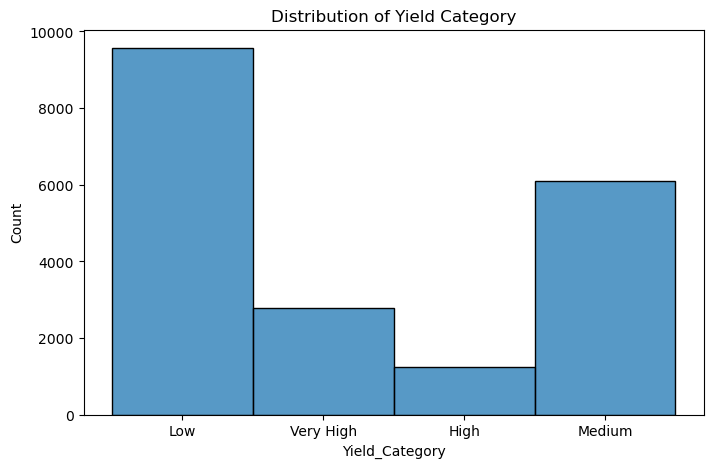

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
df["Yield_Category"]
)

plt.title(
"Distribution of Yield Category"
)

plt.show()

#### Rainfall vs Yield_Category

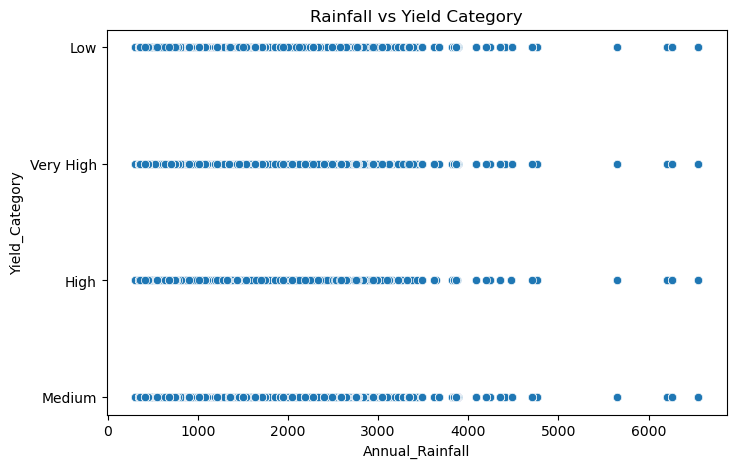

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(

x=df["Annual_Rainfall"],

y=df["Yield_Category"]

)

plt.title(
"Rainfall vs Yield Category"
)

plt.show()

### Temperature vs Yield_Category

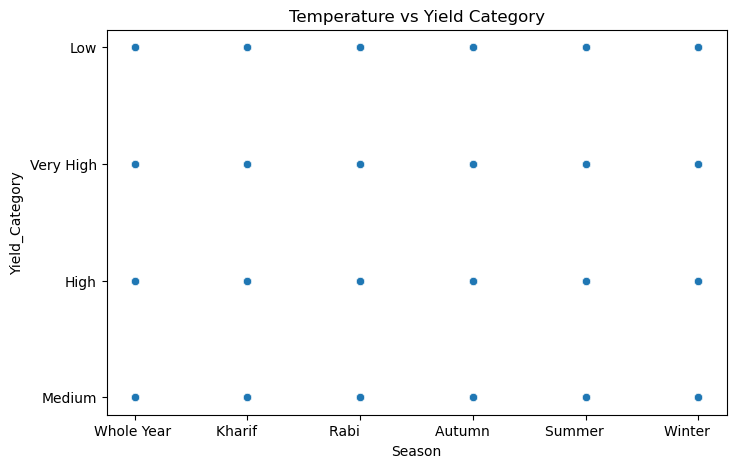

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(

x=df["Season"],

y=df["Yield_Category"]

)

plt.title(
"Temperature vs Yield Category"
)

plt.show()

### Area vs Yield_Category

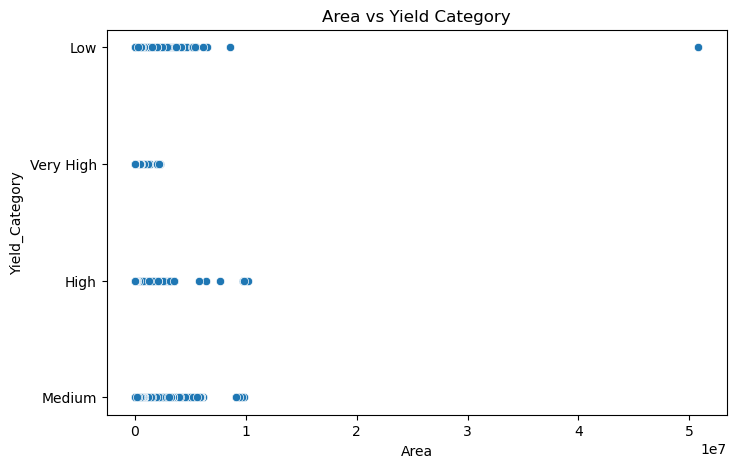

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(

x=df["Area"],

y=df["Yield_Category"]

)

plt.title(
"Area vs Yield Category"
)

plt.show()

# Q.4 Split the dataset into training and testing sets. Train a KNN model 
# and find best accuracy point by using Elbow method. Display accuracy 
# Score, Confusion Matrix, Classification Report. 

In [39]:
# Step 1 Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
# Step 2 Elbow Method for Best K
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [61]:
acc = []

for k in range(1, 21):

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        x_train,
        y_train
    )

    pred = knn.predict(
        x_test
    )

    score = accuracy_score(
        y_test,
        pred
    )

    acc.append(score)

print(acc)
print(len(acc))

[0.88268156424581, 0.8793803961401727, 0.8900457084814627, 0.882935500253936, 0.8854748603351955, 0.8844591163026917, 0.8847130523108176, 0.8824276282376841, 0.8783646521076689, 0.8760792280345353, 0.8732859319451498, 0.8694768918232605, 0.8684611477907568, 0.866937531742001, 0.8641442356526156, 0.8598273235144743, 0.8590655154900965, 0.8572879634332148, 0.8555104113763332, 0.8565261554088369]
20


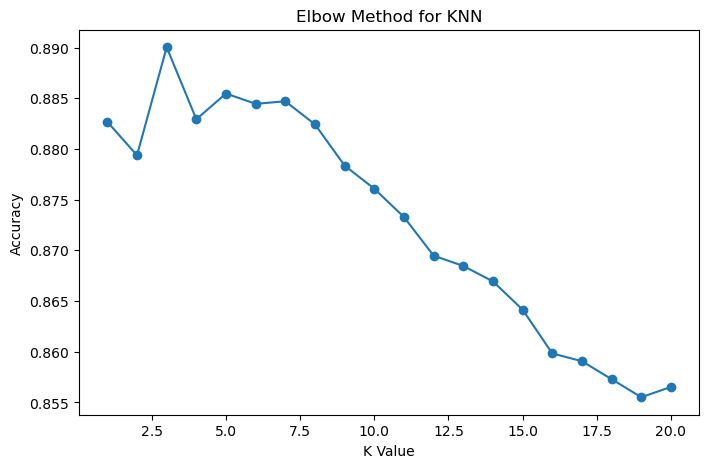

In [64]:
# Step 3 Plot Elbow Method
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 21),
    acc,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Elbow Method for KNN")
plt.show()

In [65]:
# Step 4 Final KNN Model
knn = KNeighborsClassifier(

n_neighbors=7

)

knn.fit(

x_train,

y_train

)

pred = knn.predict(

x_test
)

In [87]:
# Step 5 Accuracy Score
KNN_ACC=accuracy_score(y_test,pred)*100

In [88]:
KNN_ACC

88.47130523108177

In [69]:
# Step 6 Confusion Matrix
from sklearn.metrics import confusion_matrix

In [70]:
confusion_matrix(y_test,pred)

array([[1768,  140,    2,    6],
       [ 160, 1037,   31,    4],
       [   7,   46,  166,   23],
       [   5,    8,   22,  513]])

In [74]:
# Step 7 Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1916
           1       0.84      0.84      0.84      1232
           2       0.75      0.69      0.72       242
           3       0.94      0.94      0.94       548

    accuracy                           0.88      3938
   macro avg       0.86      0.85      0.85      3938
weighted avg       0.88      0.88      0.88      3938



# Q5. Train a Random Forest Classifier on the same data and predict 
# sales_category.find - accuracy Score, Confusion Matrix, Classification 
# Report.Compare Performance of KNN and Random Forest.  

In [75]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
RF =RandomForestClassifier(n_estimators=100,random_state=42)

In [77]:
RF.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
y_pre=RF.predict(x_test)

In [85]:
RF_ACC=accuracy_score(y_test,y_pre)*100

In [86]:
RF_ACC

98.75571356018284

In [83]:
confusion_matrix(y_test,y_pre)

array([[1900,   16,    0,    0],
       [   4, 1226,    2,    0],
       [   0,   18,  219,    5],
       [   0,    1,    3,  544]])

In [84]:
print(classification_report(y_test,y_pre))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1916
           1       0.97      1.00      0.98      1232
           2       0.98      0.90      0.94       242
           3       0.99      0.99      0.99       548

    accuracy                           0.99      3938
   macro avg       0.98      0.97      0.98      3938
weighted avg       0.99      0.99      0.99      3938



# Compare KNN vs Random Forest

In [91]:
import pandas as pd
comparison = pd.DataFrame({"Model":["KNN","Random Forest"],"Accuracy":[KNN_ACC,RF_ACC]})

print(comparison)

           Model   Accuracy
0            KNN  88.471305
1  Random Forest  98.755714


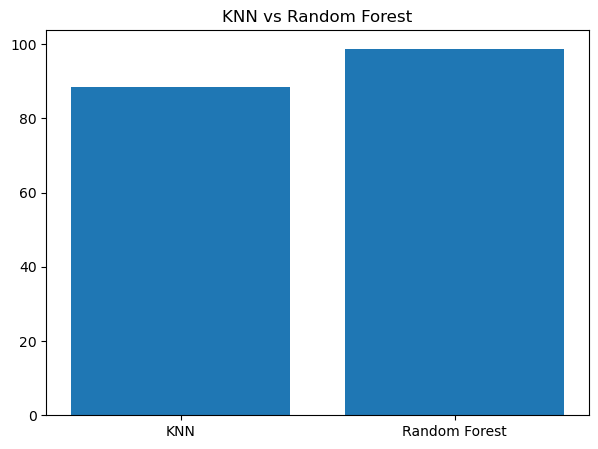

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(

comparison["Model"],

comparison["Accuracy"]

)

plt.title(

"KNN vs Random Forest"

)

plt.show()
